# Speed dating and attraction outcomes — EDA

Dataset: [sergionefedov/speed-dating-and-attraction-outcomes](https://www.kaggle.com/datasets/sergionefedov/speed-dating-and-attraction-outcomes).

Reference kernel (modeling framing): [maulikgajera/decoding-attraction-speed-dating-match](https://www.kaggle.com/code/maulikgajera/decoding-attraction-speed-dating-match).

**Grain:** one row per **speed date** (male × female pair within an `event_id`). After a short conversation, each person privately decides yes/no; `match = 1` only when **both** say yes.

**Objective:** map which pre-decision signals associate with mutual match — partner ratings, shared interests, demographics, stated preferences — and isolate the **decision leakage** trap (`male_decision` / `female_decision` deterministically define `match`).

Use this notebook for **patterns and associations**, not causal claims about real-world dating.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import kagglehub
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)

CSV_BASENAME = "speed_dating_master.csv"
KAGGLE_SLUG = "sergionefedov/speed-dating-and-attraction-outcomes"
EXPECTED_COLS = [
    "event_id",
    "male_id",
    "female_id",
    "male_age",
    "female_age",
    "age_gap",
    "same_race",
    "same_field",
    "shared_interests",
    "attr_of_female",
    "sinc_of_female",
    "intel_of_female",
    "fun_of_female",
    "amb_of_female",
    "attr_of_male",
    "sinc_of_male",
    "intel_of_male",
    "fun_of_male",
    "amb_of_male",
    "male_pref_attr",
    "male_pref_intel",
    "female_pref_attr",
    "female_pref_intel",
    "male_self_attr",
    "female_self_attr",
    "male_goes_out",
    "female_goes_out",
    "male_decision",
    "female_decision",
    "match",
]
GOES_OUT_ORDER = ["rarely", "sometimes", "often", "very_often"]
TRAITS = ["attr", "sinc", "intel", "fun", "amb"]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(CSV_BASENAME):
            assert p.is_file()
            return p
        for p in kaggle_root.rglob("*.csv"):
            if "speed_dating" in p.name.lower() or "dating" in p.name.lower():
                assert p.is_file()
                return p
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / CSV_BASENAME
    assert p.exists(), f"expected {CSV_BASENAME} under {root}"
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert df.shape[0] > 0 and df.shape[1] >= len(EXPECTED_COLS)
assert df.isna().sum().sum() == 0, "expected zero missing values"
assert set(df["male_goes_out"].unique()) <= set(GOES_OUT_ORDER)
assert set(df["female_goes_out"].unique()) <= set(GOES_OUT_ORDER)

df["male_goes_out"] = pd.Categorical(df["male_goes_out"], categories=GOES_OUT_ORDER, ordered=True)
df["female_goes_out"] = pd.Categorical(
    df["female_goes_out"], categories=GOES_OUT_ORDER, ordered=True
)

print(df.shape[0], "rows ×", df.shape[1], "cols")
display(df.sample(5, random_state=7))
display(df.dtypes)

CSV: /kaggle/input/datasets/sergionefedov/speed-dating-and-attraction-outcomes/speed_dating_master.csv
14504 rows × 30 cols


,event_id,male_id,female_id,male_age,female_age,age_gap,same_race,same_field,shared_interests,attr_of_female,...,male_pref_intel,female_pref_attr,female_pref_intel,male_self_attr,female_self_attr,male_goes_out,female_goes_out,male_decision,female_decision,match
4334,36,P00761,P00776,23,18,5,1,0,5.0,8.6,...,25.6,31.1,26.5,7.8,9.5,sometimes,sometimes,1,1,1
2352,21,P00423,P00427,30,21,9,0,0,6.8,4.7,...,12.6,19.0,18.7,3.5,5.7,sometimes,sometimes,0,0,0
13545,111,P02367,P02389,23,34,11,1,0,8.0,4.3,...,19.9,37.6,10.8,6.0,3.0,very_often,often,0,0,0
11636,96,P02041,P02048,36,29,7,0,0,4.0,9.8,...,21.5,37.7,14.0,7.9,9.7,sometimes,sometimes,0,0,0
2792,24,P00494,P00503,31,29,2,0,0,6.9,7.1,...,16.8,30.2,18.1,9.1,9.4,often,often,0,0,0


event_id                int64
male_id                object
female_id              object
male_age                int64
female_age              int64
age_gap                 int64
same_race               int64
same_field              int64
shared_interests      float64
attr_of_female        float64
sinc_of_female        float64
intel_of_female       float64
fun_of_female         float64
amb_of_female         float64
attr_of_male          float64
sinc_of_male          float64
intel_of_male         float64
fun_of_male           float64
amb_of_male           float64
male_pref_attr        float64
male_pref_intel       float64
female_pref_attr      float64
female_pref_intel     float64
male_self_attr        float64
female_self_attr      float64
male_goes_out        category
female_goes_out      category
male_decision           int64
female_decision         int64
match                   int64
dtype: object

## 1 — Univariate: event structure and marginals

In [2]:
cat_cols = [
    "event_id",
    "same_race",
    "same_field",
    "male_goes_out",
    "female_goes_out",
    "male_decision",
    "female_decision",
    "match",
]
for c in cat_cols:
    vc = df[c].value_counts(dropna=False).sort_index()
    print(f"\n=== {c} (n_unique={df[c].nunique()}) ===")
    print(vc.head(12).to_string())
    if df[c].nunique() > 12:
        print("...")

print("\nParticipants:")
print("  unique males:  ", df["male_id"].nunique())
print("  unique females:", df["female_id"].nunique())
print("  unique events: ", df["event_id"].nunique())

dates_per_male = df.groupby("male_id").size()
dates_per_female = df.groupby("female_id").size()
print("\nDates per male:   median", int(dates_per_male.median()), "| min", dates_per_male.min(), "| max", dates_per_male.max())
print("Dates per female: median", int(dates_per_female.median()), "| min", dates_per_female.min(), "| max", dates_per_female.max())

identity = (df["match"] == (df["male_decision"] & df["female_decision"])).mean()
assert identity == 1.0, "match must equal male_decision AND female_decision"
print(f"\nLeakage identity holds for {identity:.1%} of rows: match == (male_decision & female_decision)")
print(f"Match rate: {df['match'].mean():.1%}")
print(f"Male yes rate: {df['male_decision'].mean():.1%} | Female yes rate: {df['female_decision'].mean():.1%}")


=== event_id (n_unique=120) ===
event_id
0      36
1     169
2      81
3     144
4     225
5     169
6     100
7     225
8      36
9     169
10    196
11    121
...

=== same_race (n_unique=2) ===
same_race
0    11190
1     3314

=== same_field (n_unique=2) ===
same_field
0    12689
1     1815

=== male_goes_out (n_unique=4) ===
male_goes_out
rarely        2289
sometimes     5870
often         4470
very_often    1875

=== female_goes_out (n_unique=4) ===
female_goes_out
rarely        2234
sometimes     5578
often         4445
very_often    2247

=== male_decision (n_unique=2) ===
male_decision
0    8228
1    6276

=== female_decision (n_unique=2) ===
female_decision
0    8253
1    6251

=== match (n_unique=2) ===
match
0    11667
1     2837

Participants:
  unique males:   1274
  unique females: 1274
  unique events:  120

Dates per male:   median 12 | min 6 | max 15
Dates per female: median 12 | min 6 | max 15

Leakage identity holds for 100.0% of rows: match == (male_decision & fema

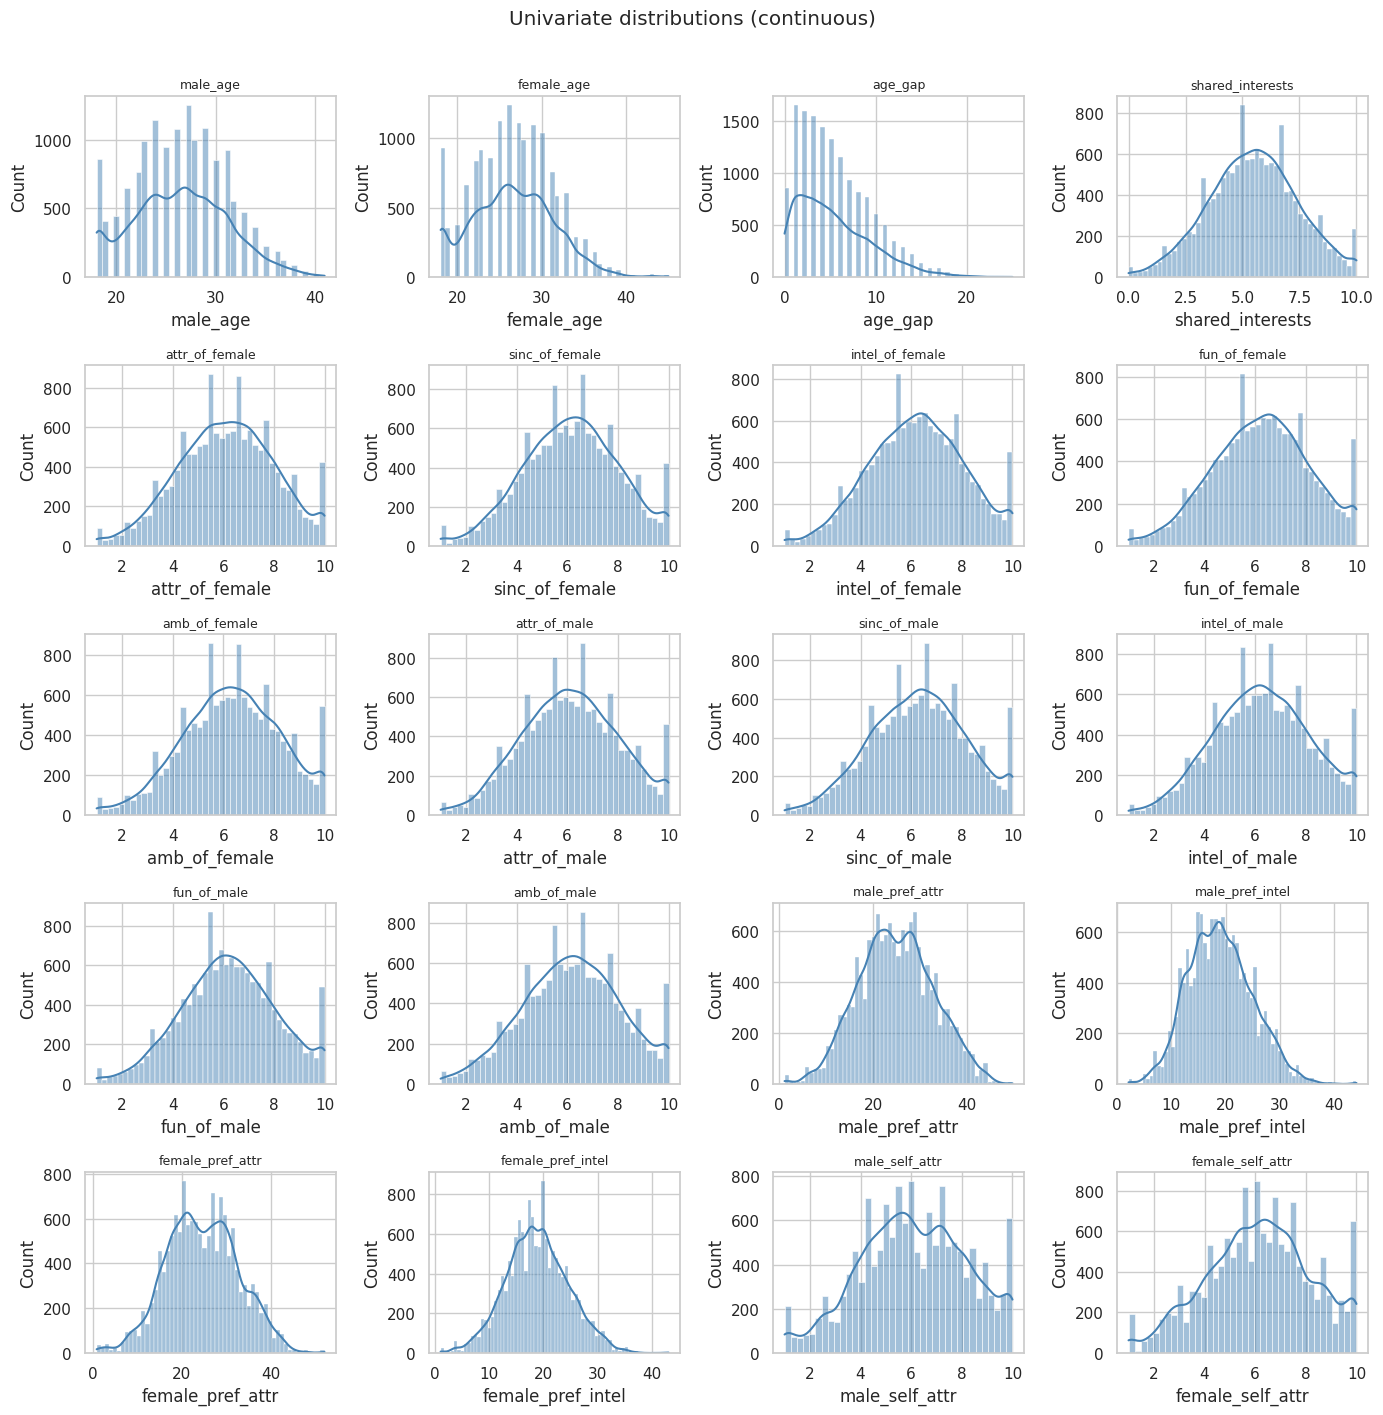

,count,mean,std,min,25%,50%,75%,max
male_age,14504.0,26.471594,4.775223,18.0,23.000,26.0,30.0,41.0
female_age,14504.0,26.537507,4.806779,18.0,23.000,26.0,30.0,45.0
age_gap,14504.0,5.401544,4.042809,0.0,2.000,5.0,8.0,25.0
shared_interests,14504.0,5.479571,1.965941,0.0,4.200,5.5,6.8,10.0
attr_of_female,14504.0,6.107288,1.898522,1.0,4.800,6.1,7.5,10.0
sinc_of_female,14504.0,6.143085,1.880768,1.0,4.800,6.2,7.5,10.0
intel_of_female,14504.0,6.191940,1.872031,1.0,4.900,6.2,7.5,10.0
fun_of_female,14504.0,6.225103,1.907833,1.0,4.900,6.3,7.5,10.0
amb_of_female,14504.0,6.301855,1.915071,1.0,5.000,6.3,7.7,10.0
attr_of_male,14504.0,6.110742,1.906214,1.0,4.800,6.1,7.5,10.0


In [3]:
cont = [
    "male_age",
    "female_age",
    "age_gap",
    "shared_interests",
    "attr_of_female",
    "sinc_of_female",
    "intel_of_female",
    "fun_of_female",
    "amb_of_female",
    "attr_of_male",
    "sinc_of_male",
    "intel_of_male",
    "fun_of_male",
    "amb_of_male",
    "male_pref_attr",
    "male_pref_intel",
    "female_pref_attr",
    "female_pref_intel",
    "male_self_attr",
    "female_self_attr",
]
fig, axes = plt.subplots(5, 4, figsize=(14, 14))
axes = axes.ravel()
for ax, col in zip(axes, cont):
    s = df[col].dropna()
    sns.histplot(s, kde=True, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=9)
plt.suptitle("Univariate distributions (continuous)", y=1.01)
plt.tight_layout()
plt.show()

display(df[cont].describe().T)

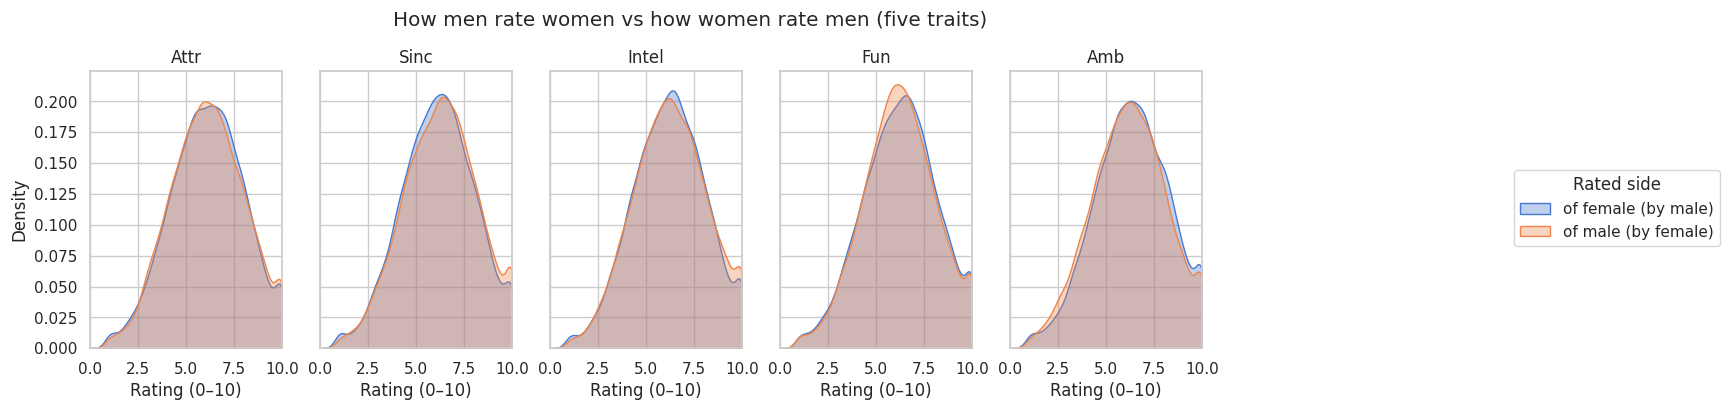

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6), sharey=True)
for ax, t in zip(axes, TRAITS):
    sns.kdeplot(df[f"{t}_of_female"], ax=ax, fill=True, alpha=0.35, label="of female (by male)")
    sns.kdeplot(df[f"{t}_of_male"], ax=ax, fill=True, alpha=0.35, label="of male (by female)")
    ax.set_title(t.capitalize())
    ax.set_xlabel("Rating (0–10)")
    ax.set_xlim(0, 10)
axes[0].set_ylabel("Density")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=True,
    title="Rated side",
)
fig.subplots_adjust(right=0.82)
fig.suptitle("How men rate women vs how women rate men (five traits)", y=1.05)
plt.show()

**Interpretation (univariate):** ~19.6% of dates end in a mutual match; each side says yes ~43% of the time. Trait rating densities for men-rating-women and women-rating-men are nearly overlapping — no large average gender skew in how generously people score partners. Ages cluster mid-20s; `age_gap` is right-skewed. Preference points (`*_pref_attr`, `*_pref_intel`) show wide individual heterogeneity. Zero missingness and near-regular dates-per-person make this an unusually clean micro-lab for association work.

**Leakage note:** `match` is *defined* as `male_decision & female_decision`. Any model that includes those decision columns is doing boolean algebra, not prediction.

## 2 — Match rate by categorical factors


=== match rate by same_race ===


,same_race,n,match_rate,match_rate_pct
0,0,11190,0.194191,19.42
1,1,3314,0.200362,20.04



=== match rate by same_field ===


,same_field,n,match_rate,match_rate_pct
0,0,12689,0.195208,19.52
1,1,1815,0.198347,19.83



=== match rate by male_goes_out ===


,male_goes_out,n,match_rate,match_rate_pct
0,rarely,2289,0.192224,19.22
1,sometimes,5870,0.196763,19.68
2,often,4470,0.201342,20.13
3,very_often,1875,0.182400,18.24



=== match rate by female_goes_out ===


,female_goes_out,n,match_rate,match_rate_pct
0,rarely,2234,0.191585,19.16
1,sometimes,5578,0.196307,19.63
2,often,4445,0.195051,19.51
3,very_often,2247,0.198932,19.89


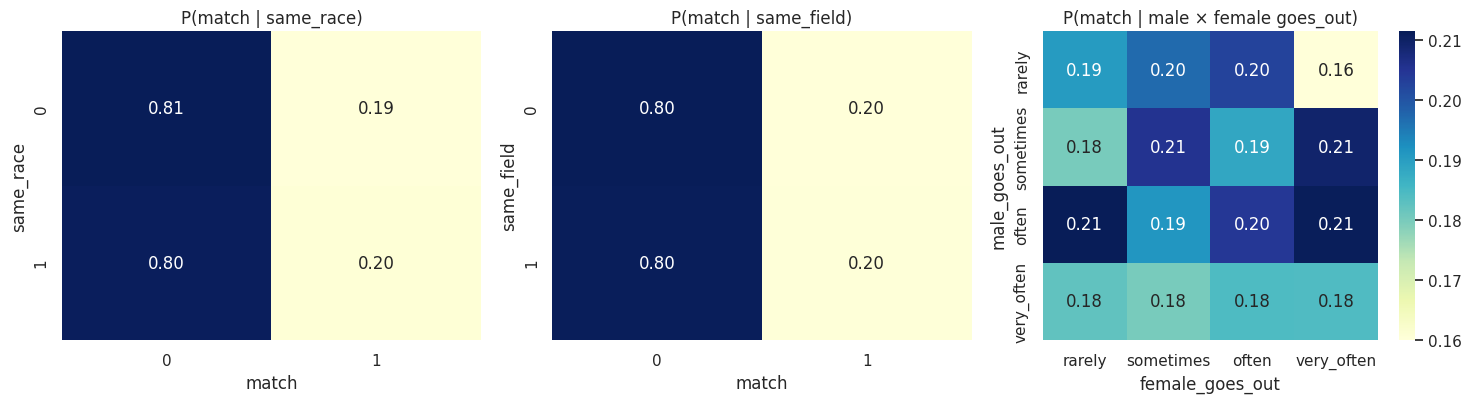

In [5]:
def match_rate_table(col: str) -> pd.DataFrame:
    g = (
        df.groupby(col, observed=True)["match"]
        .agg(n="count", match_rate="mean")
        .reset_index()
    )
    g["match_rate_pct"] = (100 * g["match_rate"]).round(2)
    return g

for col in ["same_race", "same_field", "male_goes_out", "female_goes_out"]:
    print(f"\n=== match rate by {col} ===")
    display(match_rate_table(col))

ct_race = pd.crosstab(df["same_race"], df["match"], normalize="index")
ct_field = pd.crosstab(df["same_field"], df["match"], normalize="index")
ct_goes = pd.crosstab(
    [df["male_goes_out"], df["female_goes_out"]], df["match"], normalize="index"
)[1].unstack("female_goes_out")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sns.heatmap(ct_race, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[0], cbar=False)
axes[0].set_title("P(match | same_race)")
sns.heatmap(ct_field, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1], cbar=False)
axes[1].set_title("P(match | same_field)")
sns.heatmap(ct_goes, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[2])
axes[2].set_title("P(match | male × female goes_out)")
plt.tight_layout()
plt.show()

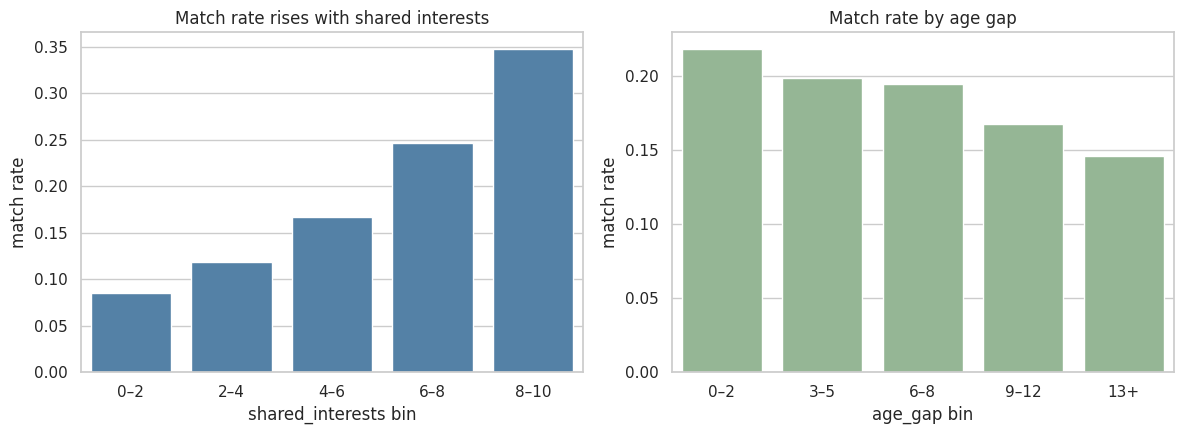

shared interests bins:


,shared_interests_bin,n,match_rate,match_rate_pct
0,0–2,622,0.085209,8.52
1,2–4,2749,0.118952,11.90
2,4–6,5506,0.167090,16.71
3,6–8,4160,0.246635,24.66
4,8–10,1467,0.348330,34.83


age gap bins:


,age_gap_bin,n,match_rate,match_rate_pct
0,0–2,4122,0.218826,21.88
1,3–5,4335,0.198847,19.88
2,6–8,2907,0.194702,19.47
3,9–12,2221,0.167942,16.79
4,13+,919,0.145811,14.58


In [6]:
df = df.copy()
df["shared_interests_bin"] = pd.cut(
    df["shared_interests"],
    bins=[0, 2, 4, 6, 8, 10],
    include_lowest=True,
    labels=["0–2", "2–4", "4–6", "6–8", "8–10"],
)
df["age_gap_bin"] = pd.cut(
    df["age_gap"],
    bins=[-0.1, 2, 5, 8, 12, 30],
    labels=["0–2", "3–5", "6–8", "9–12", "13+"],
)

si = match_rate_table("shared_interests_bin")
ag = match_rate_table("age_gap_bin")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=si, x="shared_interests_bin", y="match_rate", color="steelblue", ax=axes[0])
axes[0].set_ylabel("match rate")
axes[0].set_xlabel("shared_interests bin")
axes[0].set_title("Match rate rises with shared interests")
sns.barplot(data=ag, x="age_gap_bin", y="match_rate", color="darkseagreen", ax=axes[1])
axes[1].set_ylabel("match rate")
axes[1].set_xlabel("age_gap bin")
axes[1].set_title("Match rate by age gap")
plt.tight_layout()
plt.show()

print("shared interests bins:")
display(si)
print("age gap bins:")
display(ag)

**Interpretation (categorical):** `same_race` and `same_field` barely move match rate — demographic homophily is near-null here relative to attraction and interests. Shared interests show a clean, roughly monotonic lift in match probability. Age-gap bins are flatter. Social-frequency (`goes_out`) combinations shift rates modestly; extremes (both rarely / both very often) are worth checking against sample size in the table.

## 3 — Ratings, decisions, and the leakage trap

Pearson r with match (sorted by |r|):
female_decision     0.567
male_decision       0.565
shared_interests    0.185
attr_of_male        0.113
attr_of_female      0.109
intel_of_female     0.097
intel_of_male       0.074
fun_of_male         0.073
fun_of_female       0.070
sinc_of_male        0.061
age_gap            -0.053
amb_of_female       0.044
sinc_of_female      0.043
amb_of_male         0.031
same_race           0.007
same_field          0.003


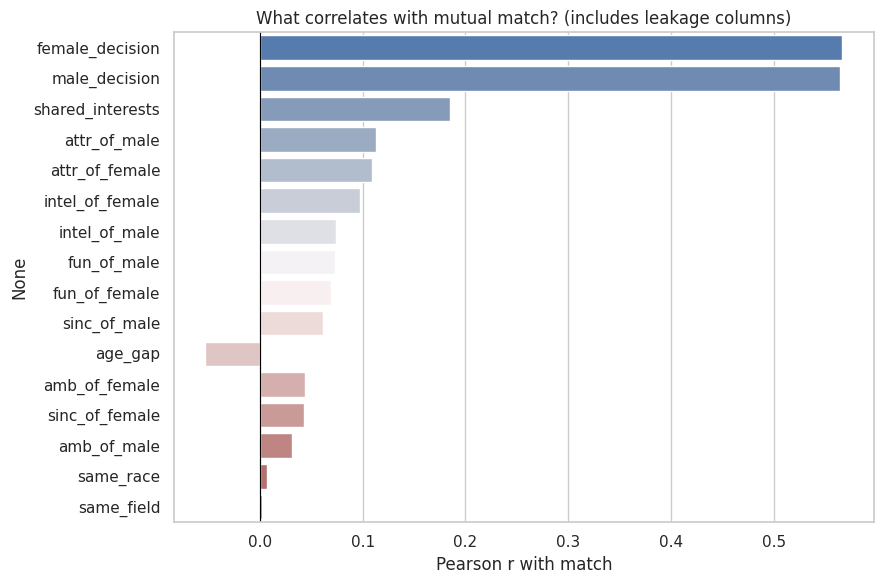


Decision × decision contingency (counts):


female_decision,0,1,All
male_decision,,,
0,4814,3414,8228
1,3439,2837,6276
All,8253,6251,14504


In [7]:
rating_cols = [f"{t}_of_female" for t in TRAITS] + [f"{t}_of_male" for t in TRAITS]
corr_with_match = (
    df[rating_cols + ["shared_interests", "age_gap", "same_race", "same_field",
                      "male_decision", "female_decision", "match"]]
    .corr(method="pearson")["match"]
    .drop("match")
    .sort_values(key=np.abs, ascending=False)
)
print("Pearson r with match (sorted by |r|):")
print(corr_with_match.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=corr_with_match.values, y=corr_with_match.index, hue=corr_with_match.index, palette="vlag", legend=False, ax=ax)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Pearson r with match")
ax.set_title("What correlates with mutual match? (includes leakage columns)")
plt.tight_layout()
plt.show()

print("\nDecision × decision contingency (counts):")
display(pd.crosstab(df["male_decision"], df["female_decision"], margins=True))

/tmp/ipykernel_16/3002046240.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="match", y=col, ax=ax, palette="pastel")
/tmp/ipykernel_16/3002046240.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="match", y=col, ax=ax, palette="pastel")
/tmp/ipykernel_16/3002046240.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="match", y=col, ax=ax, palette="pastel")
/tmp/ipykernel_16/3002046240.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assi

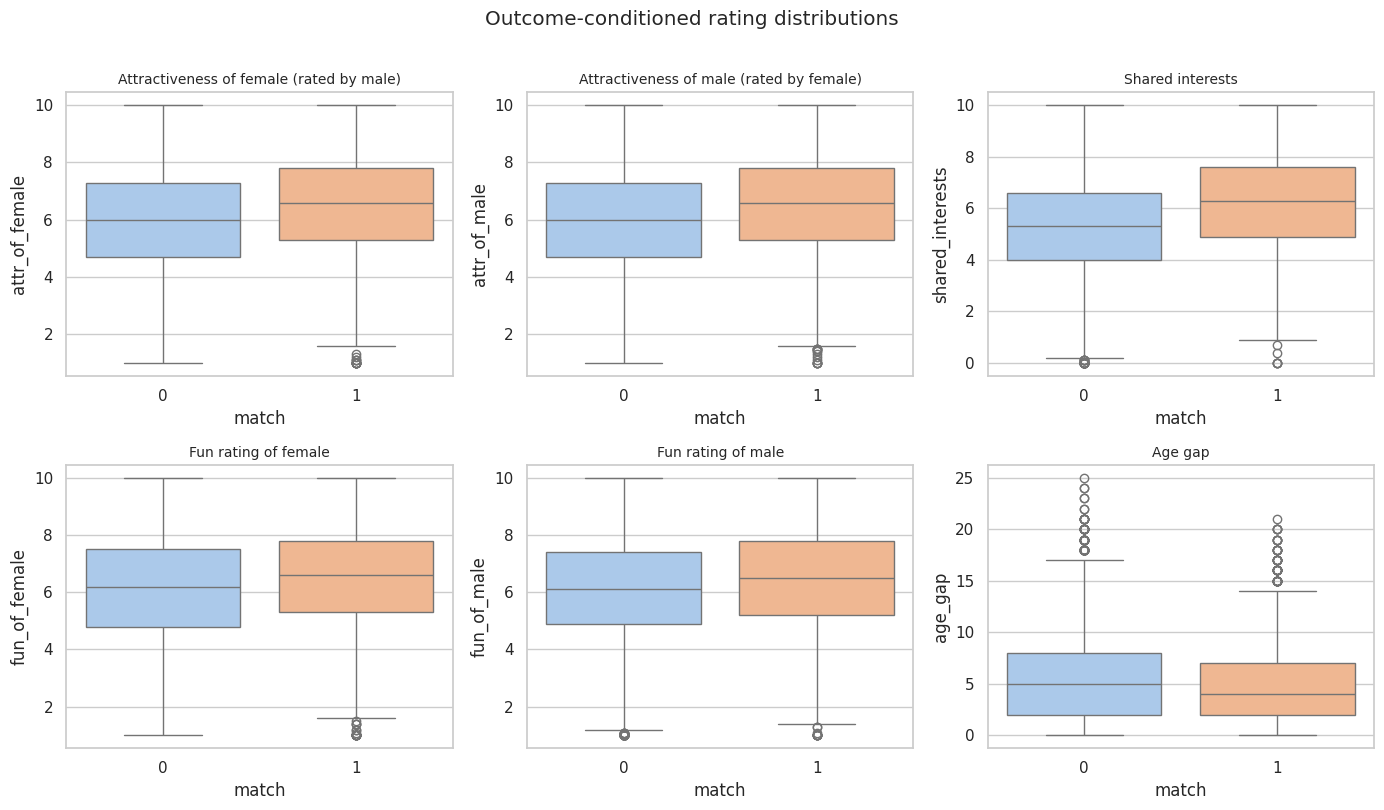

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_specs = [
    ("attr_of_female", "Attractiveness of female (rated by male)"),
    ("attr_of_male", "Attractiveness of male (rated by female)"),
    ("shared_interests", "Shared interests"),
    ("fun_of_female", "Fun rating of female"),
    ("fun_of_male", "Fun rating of male"),
    ("age_gap", "Age gap"),
]
for ax, (col, title) in zip(axes.ravel(), plot_specs):
    sns.boxplot(data=df, x="match", y=col, ax=ax, palette="pastel")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("match")
plt.suptitle("Outcome-conditioned rating distributions", y=1.01)
plt.tight_layout()
plt.show()

**Interpretation (leakage + ratings):** `male_decision` and `female_decision` dominate the correlation board (r ≈ 0.56–0.57) because they *define* `match`. Among honest pre-decision signals, `attr_of_*`, `fun_of_*`, and `shared_interests` lead; `same_race` / `same_field` / `age_gap` barely register. Boxplots show matched dates sit higher on mutual-attraction and interest axes — still associational, not proof of what "causes" a yes.

## 4 — Self-perception and stated vs revealed preferences

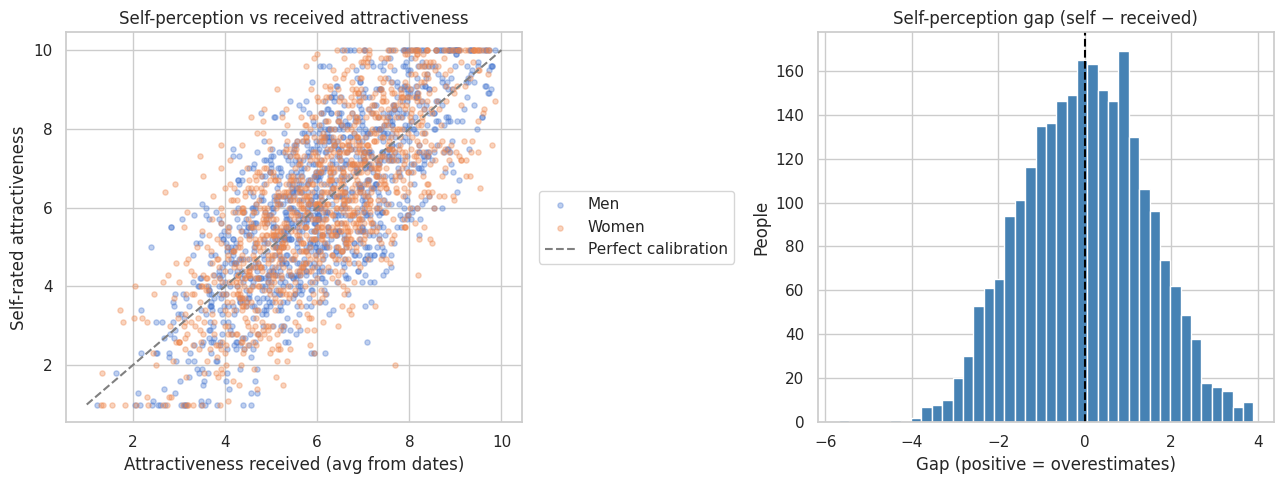

Overestimate (gap > 0.5):   37.4%
Underestimate (gap < -0.5): 36.6%
Within ±0.5:               25.9%
Mean gap (population):     +0.003


In [9]:
male_perceived = df.groupby("male_id")["attr_of_male"].mean()
male_self = df.groupby("male_id")["male_self_attr"].first()
male_gap = (male_self - male_perceived).rename("gap")

female_perceived = df.groupby("female_id")["attr_of_female"].mean()
female_self = df.groupby("female_id")["female_self_attr"].first()
female_gap = (female_self - female_perceived).rename("gap")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(male_perceived, male_self, s=14, alpha=0.35, label="Men")
axes[0].scatter(female_perceived, female_self, s=14, alpha=0.35, label="Women")
lims = [1, 10]
axes[0].plot(lims, lims, ls="--", color="gray", lw=1.5, label="Perfect calibration")
axes[0].set_xlabel("Attractiveness received (avg from dates)")
axes[0].set_ylabel("Self-rated attractiveness")
axes[0].set_title("Self-perception vs received attractiveness")
axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

both_gap = pd.concat([male_gap, female_gap])
axes[1].hist(both_gap, bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", lw=1.5)
axes[1].set_title("Self-perception gap (self − received)")
axes[1].set_xlabel("Gap (positive = overestimates)")
axes[1].set_ylabel("People")
plt.tight_layout()
plt.show()

overest = (both_gap > 0.5).mean()
underest = (both_gap < -0.5).mean()
calibrated = 1 - overest - underest
print(f"Overestimate (gap > 0.5):   {overest:.1%}")
print(f"Underestimate (gap < -0.5): {underest:.1%}")
print(f"Within ±0.5:               {calibrated:.1%}")
print(f"Mean gap (population):     {both_gap.mean():+.3f}")

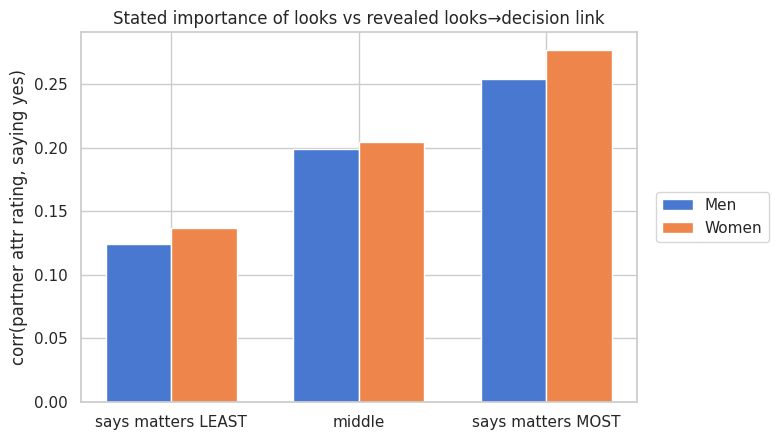

Men   corr by stated-preference tier: {'says matters LEAST': 0.124, 'middle': 0.199, 'says matters MOST': 0.254}
Women corr by stated-preference tier: {'says matters LEAST': 0.137, 'middle': 0.205, 'says matters MOST': 0.277}


In [10]:
tmp = df.copy()
tmp["male_pref_attr_tier"] = pd.qcut(
    tmp["male_pref_attr"], 3, labels=["says matters LEAST", "middle", "says matters MOST"]
)
tmp["female_pref_attr_tier"] = pd.qcut(
    tmp["female_pref_attr"], 3, labels=["says matters LEAST", "middle", "says matters MOST"]
)

male_corrs = tmp.groupby("male_pref_attr_tier", observed=True).apply(
    lambda g: g["attr_of_female"].corr(g["male_decision"]), include_groups=False
)
female_corrs = tmp.groupby("female_pref_attr_tier", observed=True).apply(
    lambda g: g["attr_of_male"].corr(g["female_decision"]), include_groups=False
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(3)
width = 0.35
ax.bar(x - width / 2, male_corrs.values, width, label="Men")
ax.bar(x + width / 2, female_corrs.values, width, label="Women")
ax.set_xticks(x)
ax.set_xticklabels(male_corrs.index)
ax.set_ylabel("corr(partner attr rating, saying yes)")
ax.set_title("Stated importance of looks vs revealed looks→decision link")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
fig.subplots_adjust(right=0.78)
plt.show()

print("Men   corr by stated-preference tier:", {k: round(v, 3) for k, v in male_corrs.items()})
print("Women corr by stated-preference tier:", {k: round(v, 3) for k, v in female_corrs.items()})

**Interpretation (calibration / preferences):** Population mean self-rating is roughly centered, but many individuals are miscalibrated both ways — over- and under-estimators cancel in the aggregate. People who *say* attractiveness matters more do show a stronger looks→yes correlation, but the tier-to-tier lift is modest next to how loudly survey preference points vary.

## 5 — Engineered fit features (pre-decision only)

Engineered / core feature correlations with match:
shared_interests             0.185
mutual_attr                  0.157
attr_of_male                 0.113
attr_of_female               0.109
mutual_fun                   0.101
pref_weighted_attr_female    0.083
pref_weighted_attr_male      0.079
rating_spread_of_male       -0.010
rating_spread_of_female     -0.024


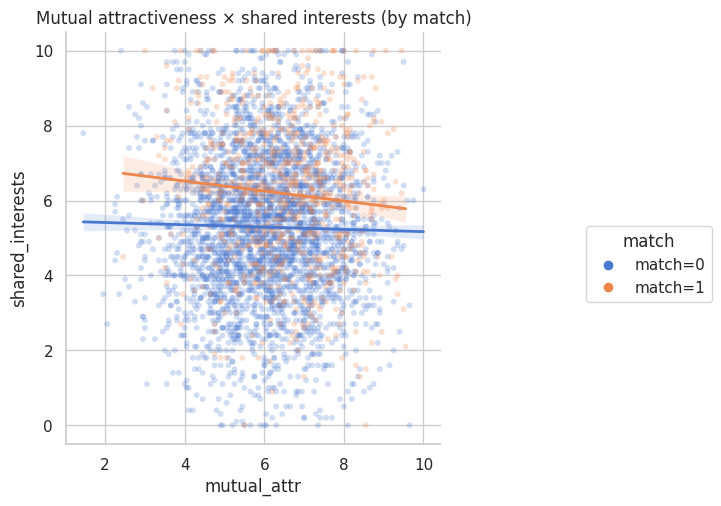


Match rate by mutual_attr quintile:
             count   mean
mutual_attr              
Q1            2971  0.117
Q2            2873  0.152
Q3            2928  0.192
Q4            2833  0.225
Q5            2899  0.294


In [11]:
df["mutual_attr"] = (df["attr_of_female"] + df["attr_of_male"]) / 2
df["mutual_fun"] = (df["fun_of_female"] + df["fun_of_male"]) / 2
df["pref_weighted_attr_male"] = (df["male_pref_attr"] / 100) * df["attr_of_female"]
df["pref_weighted_attr_female"] = (df["female_pref_attr"] / 100) * df["attr_of_male"]
df["rating_spread_of_female"] = df[[f"{t}_of_female" for t in TRAITS]].std(axis=1)
df["rating_spread_of_male"] = df[[f"{t}_of_male" for t in TRAITS]].std(axis=1)

eng_cols = [
    "mutual_attr",
    "mutual_fun",
    "pref_weighted_attr_male",
    "pref_weighted_attr_female",
    "rating_spread_of_female",
    "rating_spread_of_male",
    "shared_interests",
    "attr_of_female",
    "attr_of_male",
]
eng_corr = df[eng_cols + ["match"]].corr(method="pearson")["match"].drop("match").sort_values(ascending=False)
print("Engineered / core feature correlations with match:")
print(eng_corr.round(3).to_string())

g = sns.lmplot(
    data=df.sample(min(4000, len(df)), random_state=0),
    x="mutual_attr",
    y="shared_interests",
    hue="match",
    scatter_kws={"alpha": 0.25, "s": 18, "edgecolor": "none"},
    line_kws={"lw": 2},
    height=5,
    aspect=1.15,
    legend=False,
)
g.ax.set_title("Mutual attractiveness × shared interests (by match)")
handles, labels = g.ax.get_legend_handles_labels()
# recreate legend outside
from matplotlib.lines import Line2D
proxy = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=sns.color_palette()[i], markersize=8)
    for i in range(2)
]
g.fig.legend(proxy, ["match=0", "match=1"], loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True, title="match")
g.fig.subplots_adjust(right=0.78)
plt.show()

bins = pd.qcut(df["mutual_attr"], 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
print("\nMatch rate by mutual_attr quintile:")
print(df.groupby(bins, observed=True)["match"].agg(["count", "mean"]).round(3).to_string())

**Interpretation (engineered):** `mutual_attr` is a stronger single associate of match than either side's attractiveness alone — mutual interest in looks compounds. Preference-weighted attractiveness adds a small stated×revealed interaction. Rating *spread* (how uneven the five trait scores are) is weaker than level effects.

## 6 — Multivariate: correlation, heatmaps, feature importances

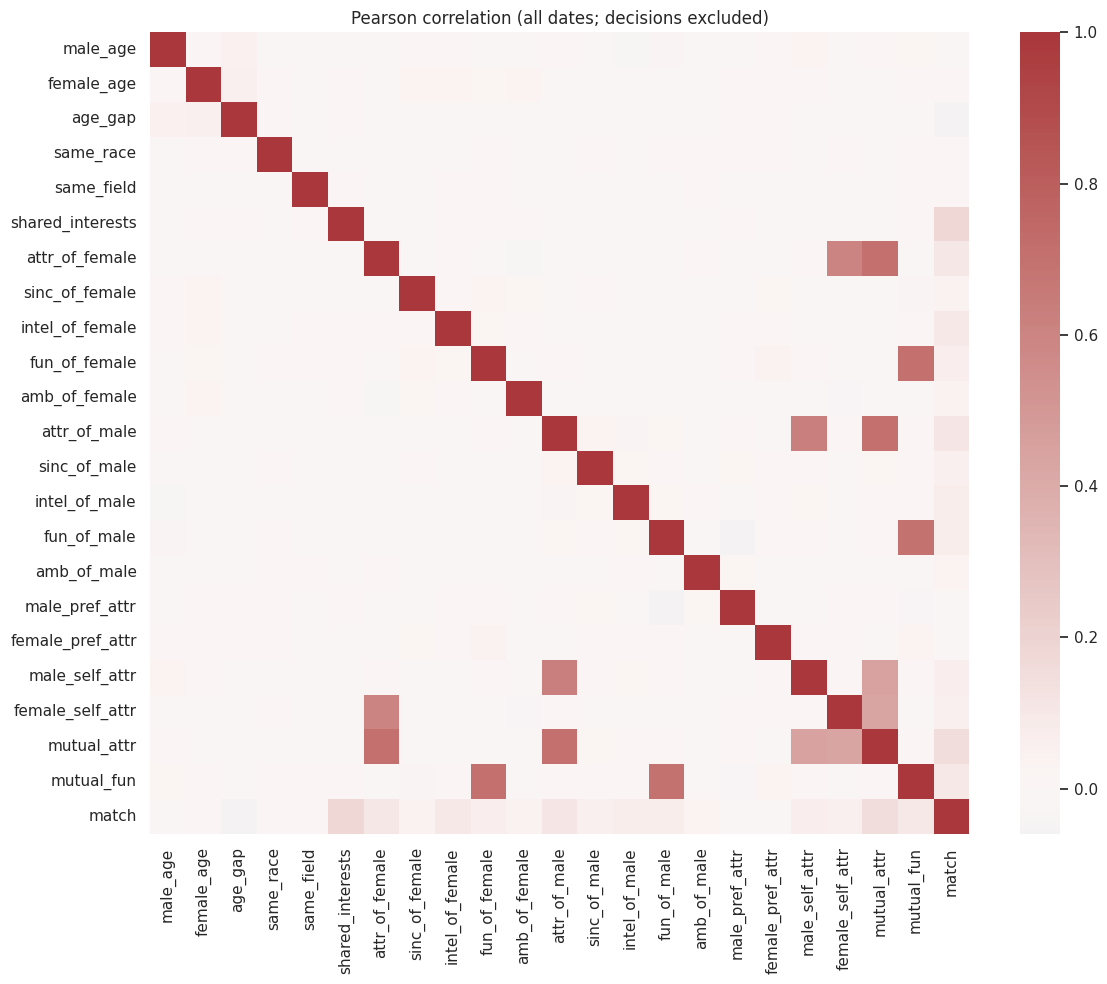

Largest |Pearson − Spearman| (robustness check, top 10):
                                pearson  spearman      diff
female_age     age_gap         0.060683  0.028111  0.032572
age_gap        female_age      0.060683  0.028111  0.032572
male_age       age_gap         0.048568  0.017878  0.030690
age_gap        male_age        0.048568  0.017878  0.030690
attr_of_male   male_self_attr  0.627034  0.607800  0.019233
male_self_attr attr_of_male    0.627034  0.607800  0.019233
fun_of_male    mutual_fun      0.696742  0.680345  0.016397
mutual_fun     fun_of_male     0.696742  0.680345  0.016397
attr_of_female mutual_attr     0.705433  0.689485  0.015948
mutual_attr    attr_of_female  0.705433  0.689485  0.015948


In [12]:
num_for_corr = [
    "male_age",
    "female_age",
    "age_gap",
    "same_race",
    "same_field",
    "shared_interests",
    "attr_of_female",
    "sinc_of_female",
    "intel_of_female",
    "fun_of_female",
    "amb_of_female",
    "attr_of_male",
    "sinc_of_male",
    "intel_of_male",
    "fun_of_male",
    "amb_of_male",
    "male_pref_attr",
    "female_pref_attr",
    "male_self_attr",
    "female_self_attr",
    "mutual_attr",
    "mutual_fun",
    "match",
]
cm = df[num_for_corr].corr(method="pearson")
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="vlag", center=0)
plt.title("Pearson correlation (all dates; decisions excluded)")
plt.tight_layout()
plt.show()

spe = df[num_for_corr].corr(method="spearman")
sub = pd.DataFrame({"pearson": cm.stack(), "spearman": spe.stack()}).join(
    pd.DataFrame({"diff": (cm - spe).abs().stack()}), how="left"
)
sub = sub[sub.index.get_level_values(0) != sub.index.get_level_values(1)]
print("Largest |Pearson − Spearman| (robustness check, top 10):")
print(sub.nlargest(10, "diff")[["pearson", "spearman", "diff"]].to_string())

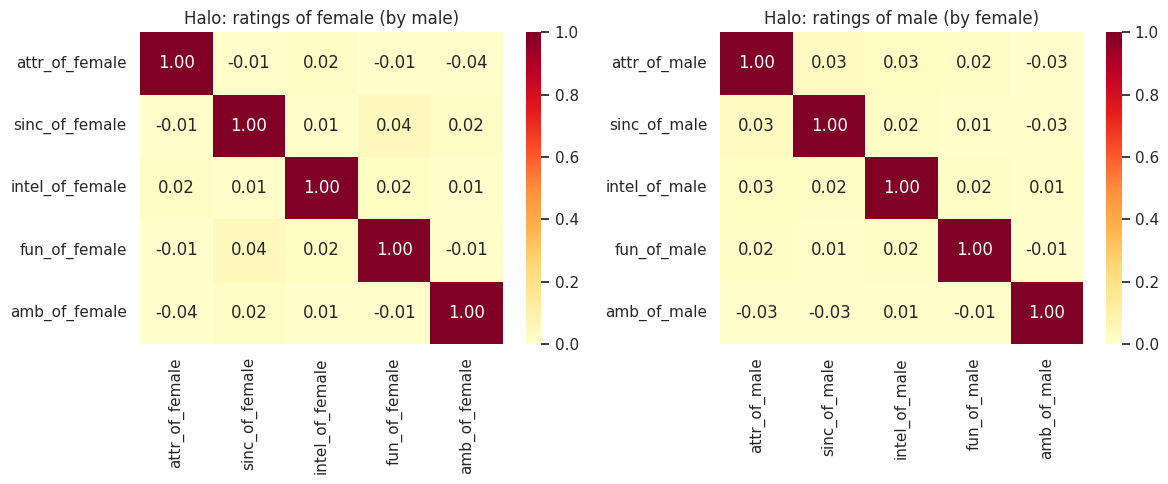

Events: 120 | corr(mean mutual_attr, match_rate) = 0.396 (p=7.75e-06)


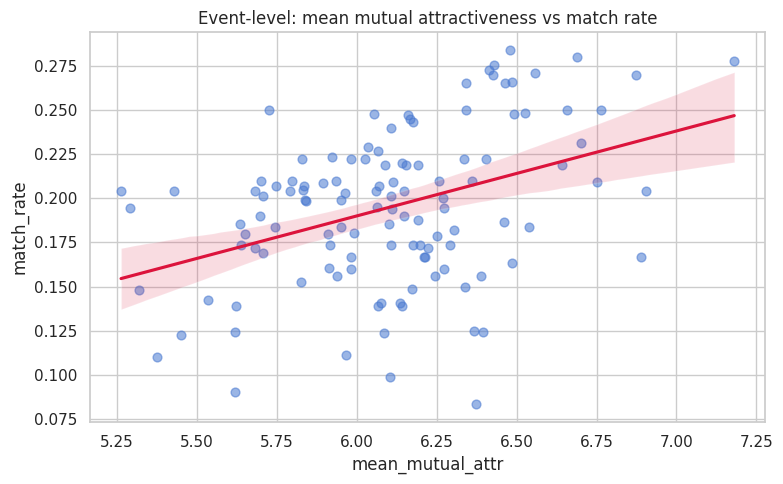

In [13]:
# Halo effect within each side's rating vector
female_ratings = df[[f"{t}_of_female" for t in TRAITS]].corr()
male_ratings = df[[f"{t}_of_male" for t in TRAITS]].corr()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(female_ratings, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Halo: ratings of female (by male)")
sns.heatmap(male_ratings, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Halo: ratings of male (by female)")
plt.tight_layout()
plt.show()

# Event-level match rates vs mean mutual attraction
event_summary = (
    df.groupby("event_id", observed=True)
    .agg(n=("match", "size"), match_rate=("match", "mean"), mean_mutual_attr=("mutual_attr", "mean"))
    .reset_index()
)
r_event, p_event = stats.pearsonr(event_summary["mean_mutual_attr"], event_summary["match_rate"])
print(f"Events: {len(event_summary)} | corr(mean mutual_attr, match_rate) = {r_event:.3f} (p={p_event:.2e})")

plt.figure(figsize=(8, 5))
sns.regplot(
    data=event_summary,
    x="mean_mutual_attr",
    y="match_rate",
    scatter_kws={"alpha": 0.55, "s": 40},
    line_kws={"color": "crimson"},
)
plt.title("Event-level: mean mutual attractiveness vs match rate")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/ax

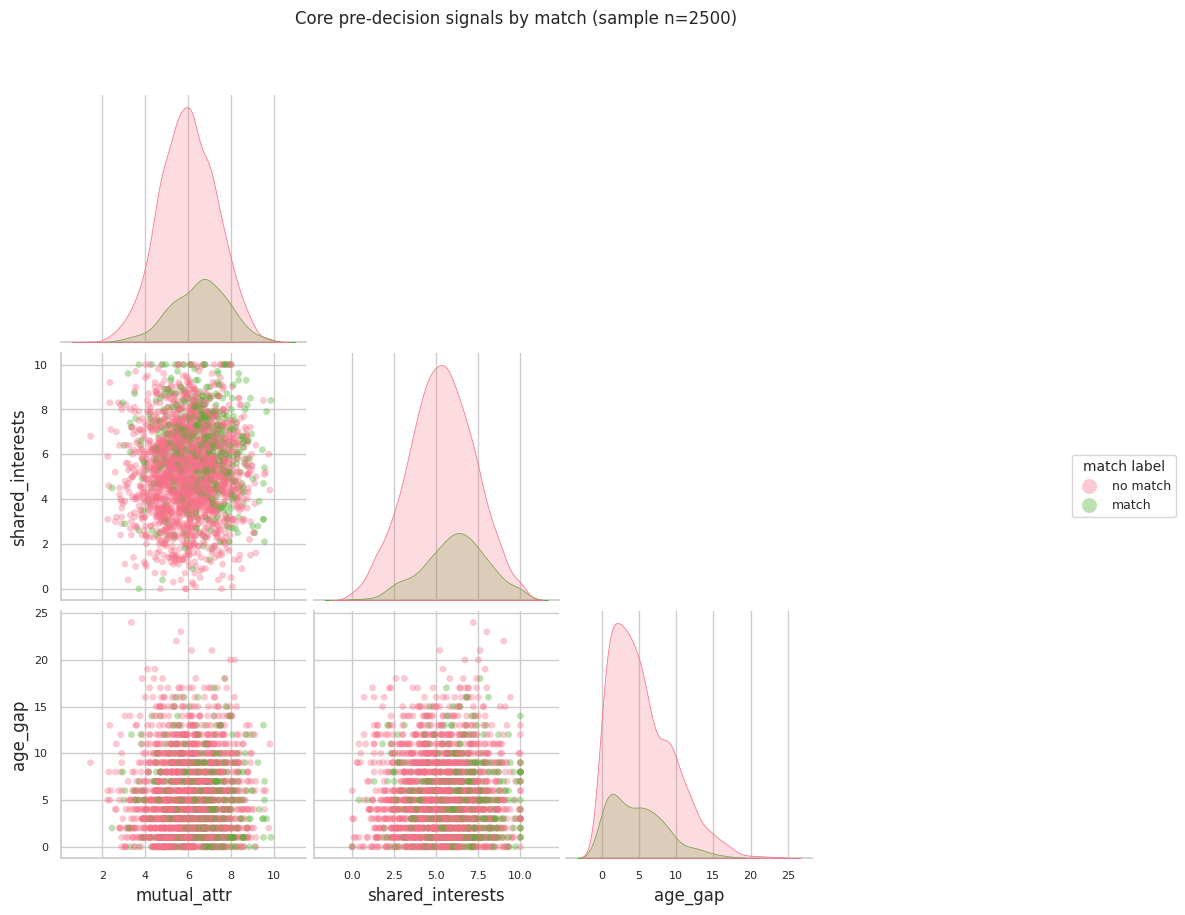

In [14]:
PAIR_SUBSET_N = min(2500, len(df))
rng = np.random.default_rng(42)
pair_ix = rng.choice(len(df), size=PAIR_SUBSET_N, replace=False)
_sample = df.iloc[pair_ix].reset_index(drop=True).copy()
_sample["match_label"] = _sample["match"].map({0: "no match", 1: "match"})

cols_core = ["mutual_attr", "shared_interests", "age_gap"]


def pairplot_big_legend(data, cols, hue, title):
    hue_n = int(data[hue].nunique())
    palette = sns.color_palette("husl", n_colors=max(hue_n, 3))
    g = sns.pairplot(
        data[cols + [hue]],
        hue=hue,
        corner=True,
        height=3.1,
        aspect=1.0,
        plot_kws={"alpha": 0.38, "s": 24, "edgecolor": "none", "linewidth": 0},
        diag_kws={"linewidth": 0.55},
        palette=palette,
    )
    g.figure.suptitle(title, y=1.012, fontsize=12)
    for ax in g.figure.axes:
        ax.tick_params(axis="both", labelsize=8)
    if g._legend is not None:
        sns.move_legend(
            g,
            "center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=True,
            fontsize=9,
            title=str(hue).replace("_", " "),
            title_fontsize=10,
            markerscale=2.2,
        )
    g.figure.subplots_adjust(left=0.07, right=0.78, bottom=0.10, top=0.92)
    plt.show()


pairplot_big_legend(
    _sample,
    cols_core,
    "match_label",
    f"Core pre-decision signals by match (sample n={len(_sample)})",
)

Top RandomForest feature importances (predicting match; decisions excluded):
shared_interests             0.077246
mutual_attr                  0.049659
intel_of_female              0.047118
mutual_fun                   0.043375
intel_of_male                0.042141
attr_of_male                 0.041575
attr_of_female               0.040703
pref_weighted_attr_female    0.040441
sinc_of_male                 0.040101
pref_weighted_attr_male      0.039818
sinc_of_female               0.039780
amb_of_female                0.039731
fun_of_male                  0.038582
amb_of_male                  0.037895
female_pref_intel            0.037527
male_pref_intel              0.036895
fun_of_female                0.036831
female_pref_attr             0.036770


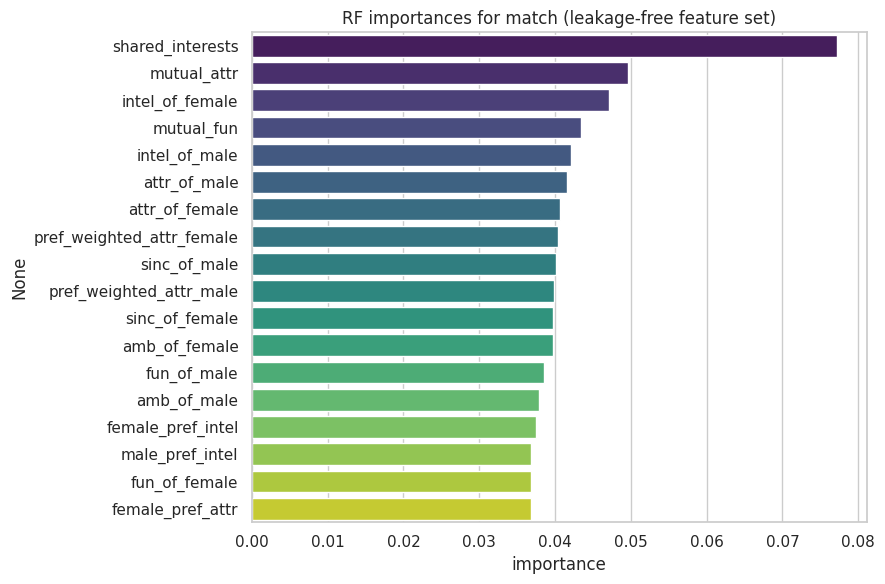

In [15]:
# RandomForest: predict match from pre-decision features only (no decision leakage)
feat_cat = ["male_goes_out", "female_goes_out"]
feat_num = [
    "male_age",
    "female_age",
    "age_gap",
    "same_race",
    "same_field",
    "shared_interests",
    "attr_of_female",
    "sinc_of_female",
    "intel_of_female",
    "fun_of_female",
    "amb_of_female",
    "attr_of_male",
    "sinc_of_male",
    "intel_of_male",
    "fun_of_male",
    "amb_of_male",
    "male_pref_attr",
    "male_pref_intel",
    "female_pref_attr",
    "female_pref_intel",
    "male_self_attr",
    "female_self_attr",
    "mutual_attr",
    "mutual_fun",
    "pref_weighted_attr_male",
    "pref_weighted_attr_female",
]
assert "male_decision" not in feat_num + feat_cat
assert "female_decision" not in feat_num + feat_cat

X = df[feat_cat + feat_num]
y = df["match"]
pipe = Pipeline(
    [
        (
            "prep",
            ColumnTransformer(
                [
                    ("cat", OneHotEncoder(handle_unknown="ignore"), feat_cat),
                    ("num", "passthrough", feat_num),
                ]
            ),
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200, random_state=0, n_jobs=-1, class_weight="balanced"
            ),
        ),
    ]
)
pipe.fit(X, y)
enc = pipe.named_steps["prep"].named_transformers_["cat"]
cat_names = list(enc.get_feature_names_out(feat_cat))
imp = pipe.named_steps["model"].feature_importances_
names = cat_names + feat_num
imp_s = pd.Series(imp, index=names).sort_values(ascending=False).head(18)
print("Top RandomForest feature importances (predicting match; decisions excluded):")
print(imp_s.to_string())

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=imp_s.values, y=imp_s.index, hue=imp_s.index, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("importance")
ax.set_title("RF importances for match (leakage-free feature set)")
plt.tight_layout()
plt.show()

## 7 — Synthesis

- **Grain / outcome:** 14,504 speed dates; `match` ≈ 19.6%. `match` is exactly `male_decision ∧ female_decision` — never use those decision columns as features when the target is `match`.
- **Strongest honest associates:** mutual / partner **attractiveness**, **fun**, and **shared interests**. Demographic flags (`same_race`, `same_field`) and `age_gap` are near-noise in this table.
- **Halo effect:** Within each side, the five trait ratings co-move (attractive people also get higher sincerity/fun/ambition scores), so single-trait correlations with match are partly shared variance.
- **Self-perception:** Aggregate self-ratings look calibrated; individual gaps are large and cancel. Stated preference for looks tracks a modestly stronger revealed looks→yes link.
- **Engineered fit:** `mutual_attr` (and to a lesser extent preference-weighted attractiveness) concentrates the attraction signal better than one-sided scores alone.
- **Multivariate:** Correlation heatmap + RandomForest importances (decisions excluded) agree that attraction and shared interests dominate nonlinear "what helps predict match" views — still associational, not a deployed recommender.
- **Natural next modeling step (outside this EDA):** predict each side's decision separately, then combine — matches how information is available in real time and avoids treating `match` as if partner yes/no were known up front.